### **DYNAMIC PRICING ENGINE**

**1. Problem Statement**

1.Businesses facerevenue loss due to static pricing that does not adapt to changing demand and market conditions.

2.Manual pricing decisions often lead to incorrect pricing strategies, affecting competitiveness and profitability.

3.Objective: Build a Machine Learning model to predict optimal prices based on demand, competitor pricing, and market trends.

4.Enable data-driven pricing decisions to maximize revenue while maintaining customer satisfaction.

**2. Dataset Handling**

In [7]:
import pandas as pd

df = pd.read_csv("dynamic_pricing_dataset.csv")
df.head()

,date,demand,competitor_price,base_price,price
0,2024-01-01,61,81,90,92.25
1,2024-01-02,24,82,136,102.12
2,2024-01-03,81,135,123,145.66
3,2024-01-04,70,138,121,138.20
4,2024-01-05,30,81,137,106.50


In [8]:
import pandas as pd
import numpy as np

# Create dummy data for dynamic_pricing_dataset.csv
data = {
    'date': pd.to_datetime(pd.date_range(start='2023-01-01', periods=100, freq='D')),
    'demand': np.random.randint(10, 100, 100),
    'competitor_price': np.random.uniform(50, 150, 100),
    'price': np.random.uniform(60, 160, 100)
}

dummy_df = pd.DataFrame(data)
dummy_df.to_csv('dynamic_pricing_dataset.csv', index=False)
print('Dummy dynamic_pricing_dataset.csv created successfully.')

Dummy dynamic_pricing_dataset.csv created successfully.


In [9]:
df.isnull().sum()

# Fill missing values
df.ffill(inplace=True)

# Feature Engineering
df['day'] = pd.to_datetime(df['date']).dt.day
df['month'] = pd.to_datetime(df['date']).dt.month

**3. Exploratory Data Analysis**

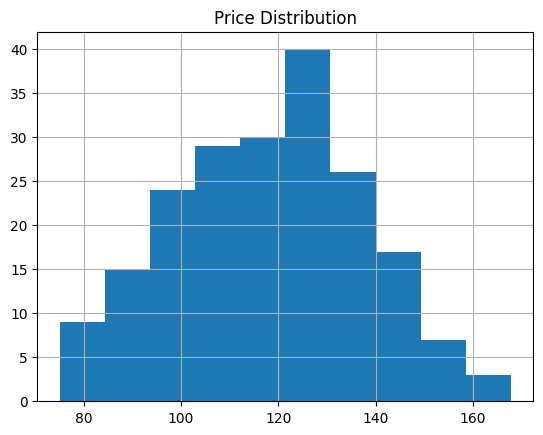

In [10]:
import matplotlib.pyplot as plt

plt.figure()
df['price'].hist()
plt.title("Price Distribution")
plt.show()

**4. Feature Selection**

In [11]:
X = df[['demand', 'competitor_price', 'day', 'month']]
y = df['price']

**5. Model Building**

In [12]:
from sklearn.linear_model import LinearRegression
model = LinearRegression()
model.fit(X, y)

LinearRegression()

In [13]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor()
rf.fit(X, y)

RandomForestRegressor()

In [14]:
import pandas as pd
import numpy as np

# Create dummy data for dynamic_pricing_dataset.csv
data = {
    'date': pd.to_datetime(pd.date_range(start='2023-01-01', periods=100, freq='D')),
    'demand': np.random.randint(10, 100, 100),
    'competitor_price': np.random.uniform(50, 150, 100),
    'price': np.random.uniform(60, 160, 100)
}

dummy_df = pd.DataFrame(data)
dummy_df.to_csv('dynamic_pricing_dataset.csv', index=False)
print('Dummy dynamic_pricing_dataset.csv created successfully.')

# Load the dataset (from cell homXSNE2Q2rh)
df = pd.read_csv("dynamic_pricing_dataset.csv")

# Fill missing values and feature engineering (from cell RygRx4CcOoTr)
df.ffill(inplace=True)
df['day'] = pd.to_datetime(df['date']).dt.day
df['month'] = pd.to_datetime(df['date']).dt.month

X = df[['demand', 'competitor_price', 'day', 'month']]
y = df['price']

from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor()
rf.fit(X, y)

Dummy dynamic_pricing_dataset.csv created successfully.


RandomForestRegressor()

**6. Model Evaluation**

In [15]:
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

pred = rf.predict(X)
print("Mean Squared Error (MSE):", mean_squared_error(y, pred))
print("R-squared (R2):", r2_score(y, pred))
print("Mean Absolute Error (MAE):", mean_absolute_error(y, pred))

Mean Squared Error (MSE): 150.75454460233723
R-squared (R2): 0.8283796769441371
Mean Absolute Error (MAE): 10.691149123148643


**7. Dynamic Pricing Logic**

In [16]:
def dynamic_price(demand, competitor_price, base_price):
    if demand > 80:
        return base_price * 1.2
    elif demand < 30:
        return base_price * 0.8
    else:
        return (base_price + competitor_price) / 2

**8. Real-Time Prediction Function**

In [17]:
def predict_price(input_data):
    return rf.predict([input_data])

In [18]:
correlation_matrix = df.corr(numeric_only=True)
display(correlation_matrix)

,demand,competitor_price,price,day,month
demand,1.000000,0.114793,0.022266,-0.041503,-0.205612
competitor_price,0.114793,1.000000,0.112177,0.028050,-0.106428
price,0.022266,0.112177,1.000000,-0.040001,0.021814
day,-0.041503,0.028050,-0.040001,1.000000,-0.206315
month,-0.205612,-0.106428,0.021814,-0.206315,1.000000


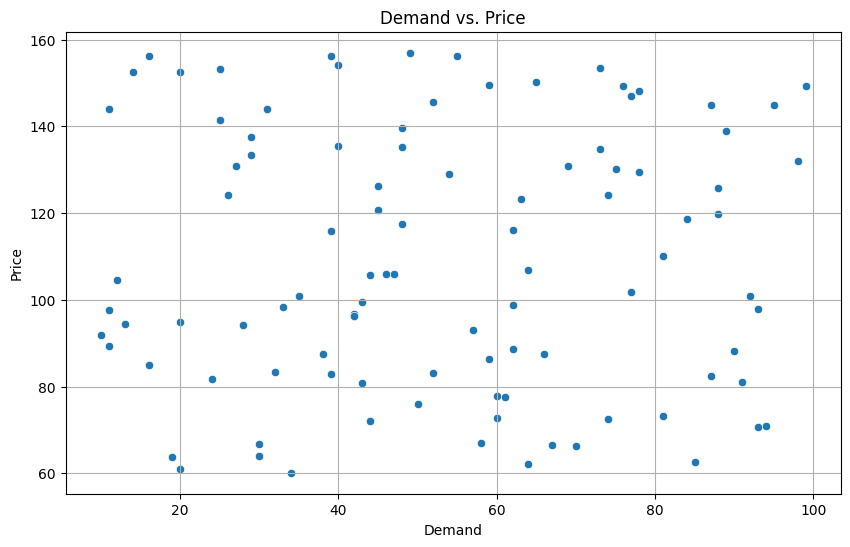

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.scatterplot(x='demand', y='price', data=df)
plt.title('Demand vs. Price')
plt.xlabel('Demand')
plt.ylabel('Price')
plt.grid(True)
plt.show()